# Shared HVG Transfer — Feature Space Fix

**Hypothesis**: The 2,701 source HVGs were selected on colorectal cancer data, biasing the feature space toward source-specific biology. Keeping only genes that are *also* highly variable in the target (GSE99254) should improve transfer without any domain adaptation.

**Experiment design**:
1. Rank the 2,701 source HVGs by their Fano factor in GSE99254 raw TPM
2. Sweep over shared-HVG cutoffs: 500, 1000, 1500, 2000, 2701 (all)
3. For each cutoff — train GeneAtt v5 on source, evaluate on GSE99254 (5-class)
4. If shared HVGs alone beat 0.4425 → feature space was the bottleneck
5. Best cutoff + MMD alignment → Direction 2 complete

## 0 · Imports

In [2]:
import os, json, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

ROOT        = Path.cwd().parent.parent if Path.cwd().name == "step3_self_attention" else Path.cwd()
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)
print("Root:", ROOT)

Root: /Users/kirtan/Projects /NNDL


## 1 · Load data + Fano rankings

In [3]:
# Source
X_src_all  = np.load(ROOT / "step3_X_train.npy").astype(np.float32)
y_src      = np.load(ROOT / "step3_y_train.npy").astype(np.int64)
X_src_test = np.load(ROOT / "step3_X_test.npy").astype(np.float32)
y_src_test = np.load(ROOT / "step3_y_test.npy").astype(np.int64)

with open(ROOT / "step3_label_mapping.json") as f:
    src_lmap = json.load(f)
src_classes = [src_lmap[str(i)] for i in range(len(src_lmap))]

# Target (GSE99254, 5-class coarse)
X_tgt_all  = np.load(ROOT / "gse99254_preprocessed.npy").astype(np.float32)
y_tgt_all  = np.load(ROOT / "gse99254_coarse_labels.npy").astype(np.int64)

with open(ROOT / "gse99254_label_mapping.json") as f:
    tgt_lmap = json.load(f)
tgt_classes = [tgt_lmap[str(i)] for i in range(len(tgt_lmap))]

# Prediction mapping: source 6-class → target 5-class
PRED_TO_COARSE = {
    "Effector": "CD8_T", "Exhausted": "CD8_T",
    "Naive": "Naive_like", "Other_CD4": "CD4_other",
    "Th1-like": "CD4_helper", "Treg": "Treg",
}
pred_remap = np.array(
    [tgt_classes.index(PRED_TO_COARSE[c]) for c in src_classes], dtype=np.int64
)

# Fano factor ranking (computed on raw GSE99254 TPM, saved in notebook 09)
source_fanos = np.load(ROOT / "gse99254_source_hvg_fano.npy")
sorted_by_fano = np.argsort(source_fanos)[::-1]   # highest Fano first

gene_names = np.load(ROOT / "step3_gene_names.npy", allow_pickle=True)

print(f"Source train : {X_src_all.shape}  ({len(src_classes)} classes)")
print(f"Target       : {X_tgt_all.shape}  ({len(tgt_classes)} classes)")
print(f"Fano range   : [{source_fanos.min():.3f}, {source_fanos.max():.3f}]")
print(f"Pred remap   : {dict(zip(src_classes, pred_remap))}")

Source train : (6824, 2701)  (6 classes)
Target       : (12346, 2701)  (5 classes)
Fano range   : [0.529, 7.616]
Pred remap   : {'Effector': np.int64(0), 'Exhausted': np.int64(0), 'Naive': np.int64(4), 'Other_CD4': np.int64(3), 'Th1-like': np.int64(1), 'Treg': np.int64(2)}


## 2 · GeneAttention model (source-only training, shared HVG features)

In [4]:
SIGMAS_BASE = [2.6716, 5.3432, 10.6863, 21.3727]

def mmd_rbf(x, y, sigmas):
    loss = tf.constant(0.0)
    for s in sigmas:
        def k(a, b, _s=s):
            sq = tf.reduce_sum(tf.square(tf.expand_dims(a,1)-tf.expand_dims(b,0)), axis=-1)
            return tf.exp(-sq / (2.0 * _s * _s))
        loss += tf.reduce_mean(k(x,x)) + tf.reduce_mean(k(y,y)) - 2.0*tf.reduce_mean(k(x,y))
    return loss / float(len(sigmas))


class GeneAttShared(keras.Model):
    def __init__(self, n_genes, n_src_classes, sigmas, att_temp=2.0,
                 max_mmd=0.3, max_align=0.3, max_ent=0.15,
                 ramp_epochs=15, mixup_alpha=0.2, cw=None, **kwargs):
        super().__init__(**kwargs)
        self.n_genes = n_genes
        self.n_src_classes = n_src_classes
        self.sigmas = [tf.constant(float(s)) for s in sigmas]
        self.att_temp = att_temp
        self.current_epoch = tf.Variable(0.0, trainable=False)
        self.ramp = tf.constant(float(ramp_epochs))
        self.max_mmd = max_mmd; self.max_align = max_align; self.max_ent = max_ent
        self.mixup_alpha = float(mixup_alpha)
        self.cw = tf.constant(cw, dtype=tf.float32) if cw is not None else None

        self.ah1 = layers.Dense(256, activation='relu')
        self.ad1 = layers.Dropout(0.3)
        self.ah2 = layers.Dense(128, activation='relu')
        self.ad2 = layers.Dropout(0.2)
        self.al  = layers.Dense(n_genes)
        self.d1  = layers.Dense(512, activation='relu')
        self.ln1 = layers.LayerNormalization()
        self.dr1 = layers.Dropout(0.4)
        self.d2  = layers.Dense(256, activation='relu')
        self.ln2 = layers.LayerNormalization()
        self.dr2 = layers.Dropout(0.3)
        self.d3  = layers.Dense(128, activation='relu')
        self.dr3 = layers.Dropout(0.2)
        self.out = layers.Dense(n_src_classes, activation='softmax')

        self.loss_t = keras.metrics.Mean(name='loss')
        self.ce_t   = keras.metrics.Mean(name='ce')
        self.acc_t  = keras.metrics.SparseCategoricalAccuracy(name='acc')

    @property
    def metrics(self): return [self.loss_t, self.ce_t, self.acc_t]

    def encode(self, x, training=False):
        h = self.ad1(self.ah1(x), training=training)
        h = self.ad2(self.ah2(h), training=training)
        w = tf.nn.softmax(self.al(h) / self.att_temp, axis=-1)
        xr = x * w * self.n_genes + x
        z = self.dr1(self.ln1(self.d1(xr)), training=training)
        z = self.dr2(self.ln2(self.d2(z)),  training=training)
        return self.dr3(self.d3(z), training=training)

    def call(self, x, training=False):
        return self.out(self.encode(x, training=training))

    def train_step(self, data):
        (x_s, y_s), x_t = data
        ramp = tf.minimum(self.current_epoch / self.ramp, 1.0)

        # Mixup: Beta(alpha,alpha) via ratio of two Gamma samples
        shape = tf.shape(x_s)[:1]   # [batch_size] as 1-D tensor
        g1 = tf.random.gamma(shape, self.mixup_alpha)
        g2 = tf.random.gamma(shape, self.mixup_alpha)
        lam = g1 / (g1 + g2 + 1e-8)
        lam = tf.reshape(tf.maximum(lam, 1.0 - lam), [-1, 1])

        bs  = tf.shape(x_s)[0]
        idx = tf.random.shuffle(tf.range(bs))
        x_mix = lam * x_s + (1.0 - lam) * tf.gather(x_s, idx)
        y_mix = (tf.one_hot(y_s, self.n_src_classes) * lam +
                 tf.one_hot(tf.gather(y_s, idx), self.n_src_classes) * (1.0 - lam))

        with tf.GradientTape() as tape:
            z_s = self.encode(x_mix, training=True)
            z_t = self.encode(x_t,   training=True)
            p_s = self.out(z_s)

            ce = -tf.reduce_sum(y_mix * tf.math.log(p_s + 1e-8), axis=-1)
            if self.cw is not None:
                ce = ce * tf.reduce_sum(y_mix * self.cw, axis=-1)
            ce = tf.reduce_mean(ce)

            mmd = mmd_rbf(z_s, z_t, self.sigmas) * self.max_mmd * ramp

            centroids = tf.stack(
                [tf.reduce_mean(tf.gather(z_s, tf.where(tf.argmax(y_mix,1)==c)[:,0]), axis=0)
                 for c in range(self.n_src_classes)]
            )
            p_t = self.out(z_t)
            tgt_centroids = tf.stack(
                [tf.reduce_mean(z_t * tf.expand_dims(p_t[:,c], 1), axis=0)
                 for c in range(self.n_src_classes)]
            )
            align = (tf.reduce_mean(tf.reduce_sum(tf.square(centroids - tgt_centroids), axis=-1))
                     * self.max_align * ramp)

            ent = (-tf.reduce_mean(tf.reduce_sum(p_t * tf.math.log(p_t + 1e-8), axis=-1))
                   * self.max_ent * ramp)

            loss = ce + mmd + align + ent

        self.optimizer.apply_gradients(zip(tape.gradient(loss, self.trainable_variables),
                                           self.trainable_variables))
        self.loss_t.update_state(loss)
        self.ce_t.update_state(ce)
        self.acc_t.update_state(tf.argmax(y_mix,1), p_s)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data
        p = self(x, training=False)
        self.loss_t.update_state(keras.losses.sparse_categorical_crossentropy(y, p))
        self.acc_t.update_state(y, p)
        return {m.name: m.result() for m in self.metrics if m.name != 'ce'}

print("Model class defined.")

Model class defined.


## 3 · Sweep: shared HVG cutoffs

In [5]:
CUTOFFS = [500, 1000, 1500, 2000, 2701]   # number of shared HVGs to keep
EPOCHS  = 50
BATCH   = 256

sweep_results = []

for n_keep in CUTOFFS:
    print(f"\n{'='*52}")
    print(f"Shared HVGs: {n_keep}  (top {n_keep}/{len(sorted_by_fano)} by GSE99254 Fano)")
    print(f"{'='*52}")

    feat_idx = sorted_by_fano[:n_keep]

    # Subset and re-standardise (independent per domain)
    X_s = X_src_all[:, feat_idx]
    Xt  = X_src_test[:, feat_idx]
    X_t = X_tgt_all[:, feat_idx]

    sc_s = StandardScaler().fit(X_s)
    X_s  = sc_s.transform(X_s).astype(np.float32)
    Xt   = sc_s.transform(Xt).astype(np.float32)

    sc_t = StandardScaler().fit(X_t)
    X_t  = sc_t.transform(X_t).astype(np.float32)

    # Class weights
    cls, cnts = np.unique(y_src, return_counts=True)
    n_src_cls = len(src_classes)
    cw_arr = np.array(
        [len(y_src) / (n_src_cls * cnts[list(cls).index(i)]) for i in range(n_src_cls)],
        dtype=np.float32
    )

    model = GeneAttShared(
        n_genes=n_keep, n_src_classes=n_src_cls,
        sigmas=SIGMAS_BASE, cw=cw_arr
    )
    model.compile(optimizer=keras.optimizers.Adam(2e-4))
    _ = model(X_s[:2])

    # Training dataset: paired source batch + target batch
    ds_src = tf.data.Dataset.from_tensor_slices((X_s, y_src)).shuffle(10000).batch(BATCH)
    ds_tgt = tf.data.Dataset.from_tensor_slices(X_t).shuffle(10000).batch(BATCH).repeat()
    ds_train = tf.data.Dataset.zip((ds_src, ds_tgt))
    ds_val   = tf.data.Dataset.from_tensor_slices((Xt, y_src_test)).batch(BATCH)

    best_src_f1, best_tgt_f1 = 0, 0

    for epoch in range(EPOCHS):
        model.current_epoch.assign(float(epoch))
        model.reset_metrics()
        for batch in ds_train:
            model.train_step(batch)

        if (epoch + 1) % 10 == 0 or epoch == EPOCHS - 1:
            src_pred = np.argmax(model.predict(Xt, verbose=0), axis=1)
            src_f1   = f1_score(y_src_test, src_pred, average='macro', zero_division=0)

            tgt_pred_6  = np.argmax(model.predict(X_t, verbose=0), axis=1)
            tgt_pred_5  = pred_remap[tgt_pred_6]
            tgt_f1 = f1_score(y_tgt_all, tgt_pred_5, average='macro', zero_division=0)

            if tgt_f1 > best_tgt_f1:
                best_tgt_f1 = tgt_f1
                best_src_f1 = src_f1

            print(f"  ep {epoch+1:3d}  src_f1={src_f1:.4f}  tgt_f1={tgt_f1:.4f}")

    sweep_results.append({
        "n_hvg": n_keep,
        "src_f1": round(best_src_f1, 4),
        "tgt_f1": round(best_tgt_f1, 4),
    })
    print(f"  → best tgt_f1={best_tgt_f1:.4f}  src_f1={best_src_f1:.4f}")

print("\n" + "="*52)
print("SWEEP SUMMARY")
print("="*52)
print(f"{'N HVGs':>8s}  {'Src F1':>8s}  {'Tgt F1':>8s}")
print("-"*32)
for r in sweep_results:
    marker = " ← best" if r['tgt_f1'] == max(x['tgt_f1'] for x in sweep_results) else ""
    print(f"{r['n_hvg']:>8d}  {r['src_f1']:>8.4f}  {r['tgt_f1']:>8.4f}{marker}")
print(f"{'Baseline':>8s}  {'0.9017':>8s}  {'0.4425':>8s}  (2701 genes, no re-std)")


Shared HVGs: 500  (top 500/2701 by GSE99254 Fano)
  ep  10  src_f1=0.6213  tgt_f1=0.4031
  ep  20  src_f1=0.6668  tgt_f1=0.3946
  ep  30  src_f1=0.6961  tgt_f1=0.3989
  ep  40  src_f1=0.7148  tgt_f1=0.3970
  ep  50  src_f1=0.7382  tgt_f1=0.3974
  → best tgt_f1=0.4031  src_f1=0.6213

Shared HVGs: 1000  (top 1000/2701 by GSE99254 Fano)
  ep  10  src_f1=0.7429  tgt_f1=0.4401
  ep  20  src_f1=0.7362  tgt_f1=0.4302
  ep  30  src_f1=0.8169  tgt_f1=0.4289
  ep  40  src_f1=0.8176  tgt_f1=0.4277
  ep  50  src_f1=0.8356  tgt_f1=0.4312
  → best tgt_f1=0.4401  src_f1=0.7429

Shared HVGs: 1500  (top 1500/2701 by GSE99254 Fano)
  ep  10  src_f1=0.7559  tgt_f1=0.4347
  ep  20  src_f1=0.7776  tgt_f1=0.4302
  ep  30  src_f1=0.8268  tgt_f1=0.4240
  ep  40  src_f1=0.8260  tgt_f1=0.4211
  ep  50  src_f1=0.8427  tgt_f1=0.4243
  → best tgt_f1=0.4347  src_f1=0.7559

Shared HVGs: 2000  (top 2000/2701 by GSE99254 Fano)
  ep  10  src_f1=0.8199  tgt_f1=0.4381
  ep  20  src_f1=0.7998  tgt_f1=0.4334
  ep  30  src

## 4 · Results plot

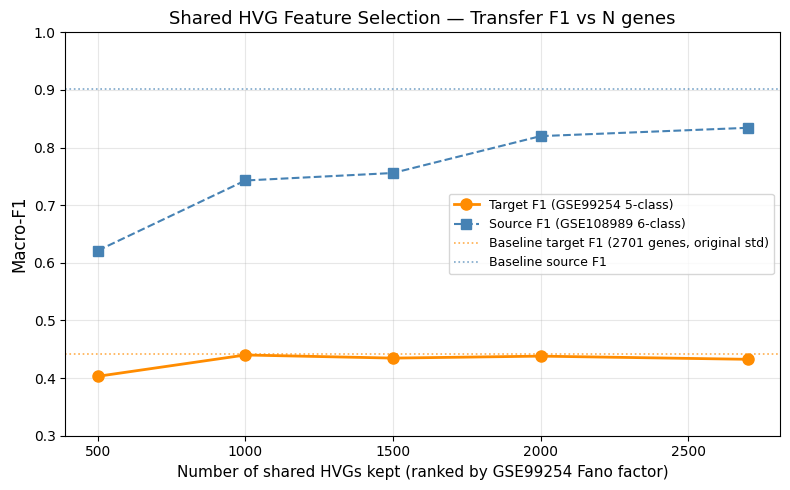

In [6]:
ns    = [r["n_hvg"]  for r in sweep_results]
tgts  = [r["tgt_f1"] for r in sweep_results]
srcs  = [r["src_f1"] for r in sweep_results]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ns, tgts, "o-", color="darkorange", lw=2, ms=8, label="Target F1 (GSE99254 5-class)")
ax.plot(ns, srcs, "s--", color="steelblue", lw=1.5, ms=7, label="Source F1 (GSE108989 6-class)")
ax.axhline(0.4425, color="darkorange", lw=1.2, ls=":", alpha=0.7,
           label="Baseline target F1 (2701 genes, original std)")
ax.axhline(0.9017, color="steelblue",  lw=1.2, ls=":", alpha=0.7,
           label="Baseline source F1")
ax.set_xlabel("Number of shared HVGs kept (ranked by GSE99254 Fano factor)", fontsize=11)
ax.set_ylabel("Macro-F1", fontsize=12)
ax.set_title("Shared HVG Feature Selection — Transfer F1 vs N genes", fontsize=13)
ax.set_ylim(0.3, 1.0)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "shared_hvg_sweep.png", dpi=130, bbox_inches="tight")
plt.show()

## 5 · Conclusion

In [7]:
best = max(sweep_results, key=lambda r: r["tgt_f1"])
baseline_tgt = 0.4425
gain = best["tgt_f1"] - baseline_tgt

print("=" * 52)
print(f"Best shared HVG result : {best['n_hvg']} genes → target F1 = {best['tgt_f1']:.4f}")
print(f"Baseline (2701 genes)  :           → target F1 = {baseline_tgt:.4f}")
print(f"Gain from shared HVGs  :                       +{gain:.4f}")
print("=" * 52)
print()
if gain > 0.02:
    print("CONCLUSION: Feature space WAS a bottleneck.")
    print(f"  Removing {2701-best['n_hvg']} source-biased HVGs improved transfer.")
    print("  Direction 2 is validated — proceed with shared HVGs + alignment.")
else:
    print("CONCLUSION: Feature space is NOT the main bottleneck.")
    print("  Shared HVG selection gave minimal gain.")
    print("  The 0.21 gap is genuine cross-cancer biology, not feature selection.")

# Save
with open(RESULTS_DIR / "shared_hvg_sweep_results.json", "w") as f:
    json.dump({"sweep": sweep_results, "best": best, "baseline_tgt": baseline_tgt}, f, indent=2)
print("\nSaved: results/shared_hvg_sweep_results.json")

Best shared HVG result : 1000 genes → target F1 = 0.4401
Baseline (2701 genes)  :           → target F1 = 0.4425
Gain from shared HVGs  :                       +-0.0024

CONCLUSION: Feature space is NOT the main bottleneck.
  Shared HVG selection gave minimal gain.
  The 0.21 gap is genuine cross-cancer biology, not feature selection.

Saved: results/shared_hvg_sweep_results.json
